In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Extraccion de datos

In [4]:
df = pd.read_json('/content/TelecomX_Data.json')

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Conocer el conjunto de datos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [6]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


# Comprobacion de incoherencias en los datos


In [7]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

## Manejo de inconstistencias

In [8]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

In [9]:
df_concat = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

In [10]:
df_concat.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [11]:
df_concat.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


In [12]:
df_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [13]:
df_concat['Charges.Total'] = pd.to_numeric(
    df_concat['Charges.Total'],
    errors='coerce'
)

In [14]:
df_concat.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
df_concat['Charges.Total'].fillna(
    df_concat['Charges.Total'].mean(),
    inplace=True
)


/tmp/ipykernel_401/1850056867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_concat['Charges.Total'].fillna(


In [16]:
df_concat.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [17]:
df_concat['Churn'].isnull().sum()

np.int64(0)

## Analisis descriptivo

In [18]:
df_concat.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2266.915104
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,401.400000
50%,0.000000,29.000000,70.300000,1394.550000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


## Distribucion de evacion

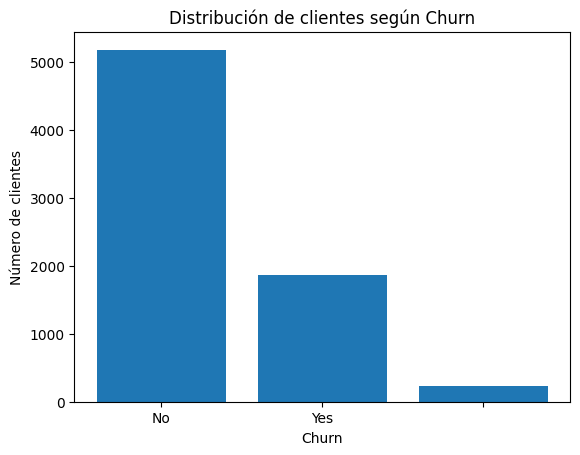

In [19]:
churn_counts = df_concat['Churn'].value_counts()

plt.figure()
plt.bar(churn_counts.index, churn_counts.values)
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.title('Distribución de clientes según Churn')
plt.show()

## Recuento de evasión por variables categóricas

In [20]:
df_prueba = df_concat.groupby(['gender', 'Contract', 'PaymentMethod'])['Churn'].value_counts().rename('count').reset_index()
df_prueba

,gender,Contract,PaymentMethod,Churn,count
0,Female,Month-to-month,Bank transfer (automatic),No,198
1,Female,Month-to-month,Bank transfer (automatic),Yes,112
2,Female,Month-to-month,Bank transfer (automatic),,10
3,Female,Month-to-month,Credit card (automatic),No,167
4,Female,Month-to-month,Credit card (automatic),Yes,103
...,...,...,...,...,...
67,Male,Two year,Electronic check,Yes,6
68,Male,Two year,Electronic check,,1
69,Male,Two year,Mailed check,No,187
70,Male,Two year,Mailed check,,6


In [21]:
df_prueba['proportion'] = (
    df_prueba['count'] /
    df_prueba.groupby(['gender', 'Contract', 'PaymentMethod'])['count'].transform('sum')
)

In [22]:
df_prueba

,gender,Contract,PaymentMethod,Churn,count,proportion
0,Female,Month-to-month,Bank transfer (automatic),No,198,0.618750
1,Female,Month-to-month,Bank transfer (automatic),Yes,112,0.350000
2,Female,Month-to-month,Bank transfer (automatic),,10,0.031250
3,Female,Month-to-month,Credit card (automatic),No,167,0.605072
4,Female,Month-to-month,Credit card (automatic),Yes,103,0.373188
...,...,...,...,...,...,...
67,Male,Two year,Electronic check,Yes,6,0.068182
68,Male,Two year,Electronic check,,1,0.011364
69,Male,Two year,Mailed check,No,187,0.963918
70,Male,Two year,Mailed check,,6,0.030928


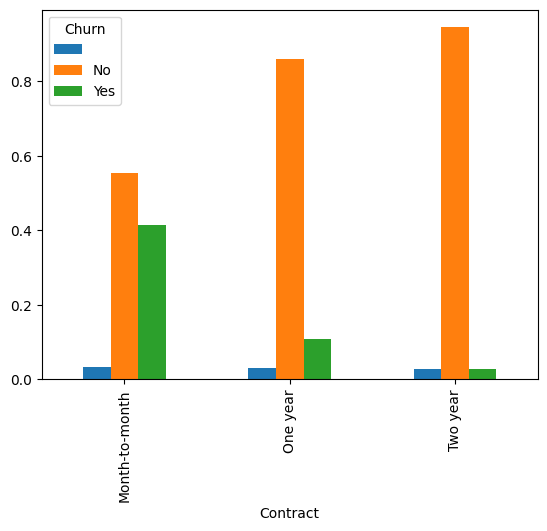

In [23]:
churn_by_contract = (
    df_concat
        .groupby('Contract')['Churn']
        .value_counts(normalize=True)
        .unstack()
)

churn_by_contract.plot(kind='bar')
plt.show()

## Conteo de evasión por variables numéricas

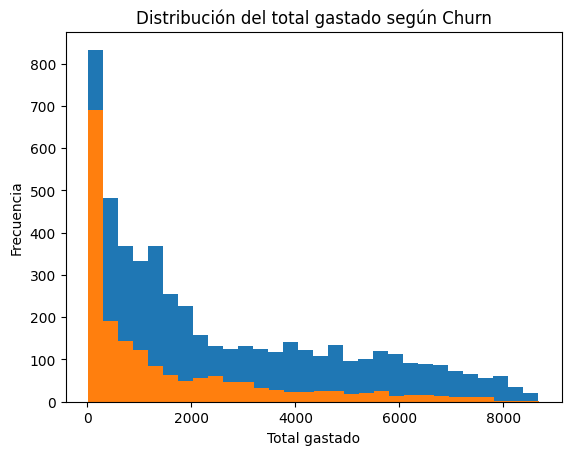

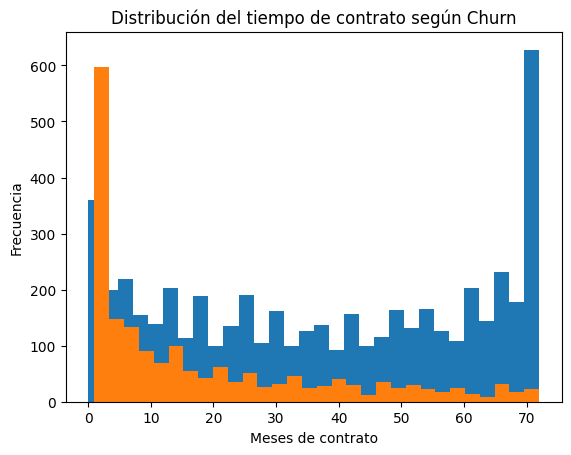

In [24]:
numeric_cols = ['Charges.Total', 'tenure']

# Separar por Churn
churn_yes = df_concat[df_concat['Churn'] == 'Yes']
churn_no = df_concat[df_concat['Churn'] == 'No']

# Histograma: Total gastado
plt.figure()
plt.hist(churn_no['Charges.Total'], bins=30)
plt.hist(churn_yes['Charges.Total'], bins=30)
plt.xlabel('Total gastado')
plt.ylabel('Frecuencia')
plt.title('Distribución del total gastado según Churn')
plt.show()

# Histograma: Tiempo de contrato (tenure)
plt.figure()
plt.hist(churn_no['tenure'], bins=30)
plt.hist(churn_yes['tenure'], bins=30)
plt.xlabel('Meses de contrato')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo de contrato según Churn')
plt.show()

# Informe final

### Introduccion

El objetivo de este análisis es comprender el fenómeno de evasión de clientes (Churn), es decir, identificar los factores asociados a que un cliente cancele el servicio.
La evasión representa un problema crítico para las empresas, ya que adquirir nuevos clientes suele ser más costoso que retener a los existentes.

### Limpieza y tratamiento de los datos

Se importaron los datos y se inspeccionó su estructura general.

Se identificaron columnas con datos anidados (formato JSON), las cuales fueron normalizadas para obtener un DataFrame plano.

Se convirtieron variables numéricas que estaban en formato object (por ejemplo, total gastado) a tipo float, manejando valores inválidos o vacíos mediante pd.to_numeric(errors='coerce').

Se revisaron valores faltantes y se decidió tratarlos de manera adecuada para evitar sesgos en el análisis.

### Analisis exploratorio de datos




Se analizó la distribución de la variable objetivo (Churn) para entender la proporción de clientes que cancelaron frente a los que permanecieron.

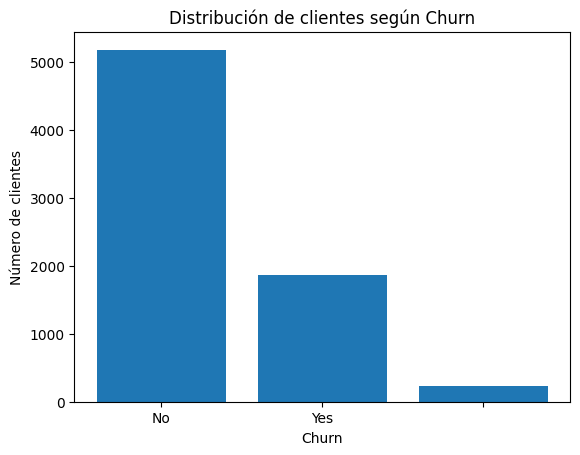

Se exploró cómo variables numéricas clave se distribuyen según el estado de evasión

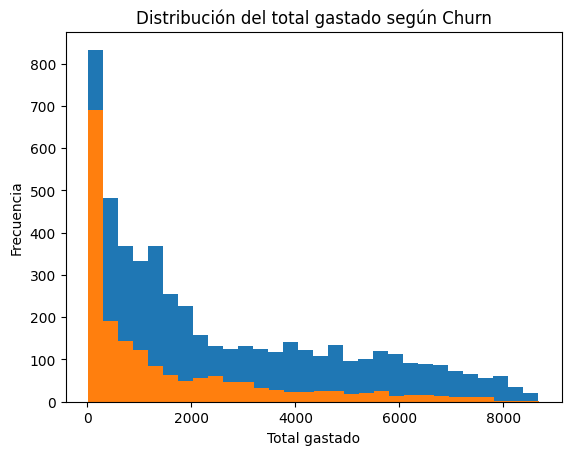


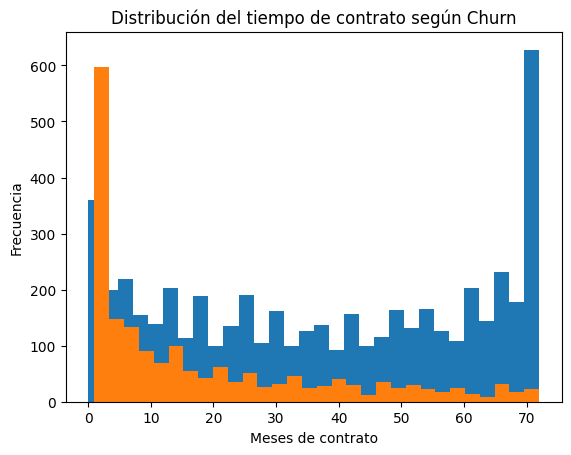

### Conclusiones

A partir del análisis exploratorio se concluye que:

La evasión de clientes no ocurre de manera aleatoria.

Variables como tiempo de contrato y total gastado están fuertemente asociadas al churn.

Los clientes nuevos y aquellos con contratos flexibles presentan mayor riesgo de cancelación.

Existe un desbalance entre clientes que cancelan y los que no, lo cual debe considerarse en modelos predictivos.

### Recomendaciones

 Implementar programas de retención temprana dirigidos a clientes durante los primeros meses de contrato.

 Incentivar contratos de mayor duración mediante descuentos o beneficios adicionales.

 Diseñar campañas personalizadas para clientes con bajo gasto acumulado.

## Parte 2


In [25]:
df_prueba.head(2)

,gender,Contract,PaymentMethod,Churn,count,proportion
0,Female,Month-to-month,Bank transfer (automatic),No,198,0.61875
1,Female,Month-to-month,Bank transfer (automatic),Yes,112,0.35000


In [26]:
import pandas as pd

# Identificamos las columnas categóricas que queremos codificar
# En df_prueba son: gender, Contract, PaymentMethod, Churn
# Nota: 'count' y 'proportion' ya son numéricas.

categorical_cols = ['gender', 'Contract', 'PaymentMethod', 'Churn']

# Aplicamos One-Hot Encoding usando pd.get_dummies
df_encoded = pd.get_dummies(df_prueba, columns=categorical_cols, drop_first=False)

display(df_encoded.head())
print("\nNuevas columnas:", df_encoded.columns.tolist())

,count,proportion,gender_Female,gender_Male,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_,Churn_No,Churn_Yes
0,198,0.618750,True,False,True,False,False,True,False,False,False,False,True,False
1,112,0.350000,True,False,True,False,False,True,False,False,False,False,False,True
2,10,0.031250,True,False,True,False,False,True,False,False,False,True,False,False
3,167,0.605072,True,False,True,False,False,False,True,False,False,False,True,False
4,103,0.373188,True,False,True,False,False,False,True,False,False,False,False,True



Nuevas columnas: ['count', 'proportion', 'gender_Female', 'gender_Male', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_', 'Churn_No', 'Churn_Yes']


In [ ]:
df_encoded

In [27]:
# Calculate the total count of each class using the 'Churn' column from the original df_concat
# or by summing the encoded columns in df_encoded if applicable.
# Since df_encoded was derived from df_prueba (a grouped summary),
# it's better to use the original df_concat to get the true distribution of the full dataset.

churn_counts = df_concat['Churn'].value_counts()
churn_proportions = df_concat['Churn'].value_counts(normalize=True) * 100

# Create a summary DataFrame
churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_proportions
})

display(churn_summary)

# Quick evaluation of imbalance
print(f"\nProporción de Churn (Yes): {churn_proportions.get('Yes', 0):.2f}%")
print(f"Proporción de No Churn (No): {churn_proportions.get('No', 0):.2f}%")

,Count,Percentage (%)
Churn,,
No,5174,71.198569
Yes,1869,25.719004
,224,3.082427



Proporción de Churn (Yes): 25.72%
Proporción de No Churn (No): 71.20%


In [28]:
import pandas as pd

# Inspect the summary statistics of numeric columns in df_encoded
numeric_summary = df_encoded[['count', 'proportion']].describe()
print("Summary statistics for 'count' and 'proportion':")
display(numeric_summary)

Summary statistics for 'count' and 'proportion':


,count,proportion
count,72.000000,72.000000
mean,100.930556,0.333333
std,127.320304,0.361226
min,1.000000,0.005155
25%,7.000000,0.030159
50%,22.500000,0.097653
75%,175.250000,0.660784
max,502.000000,0.963918


## Correlacion

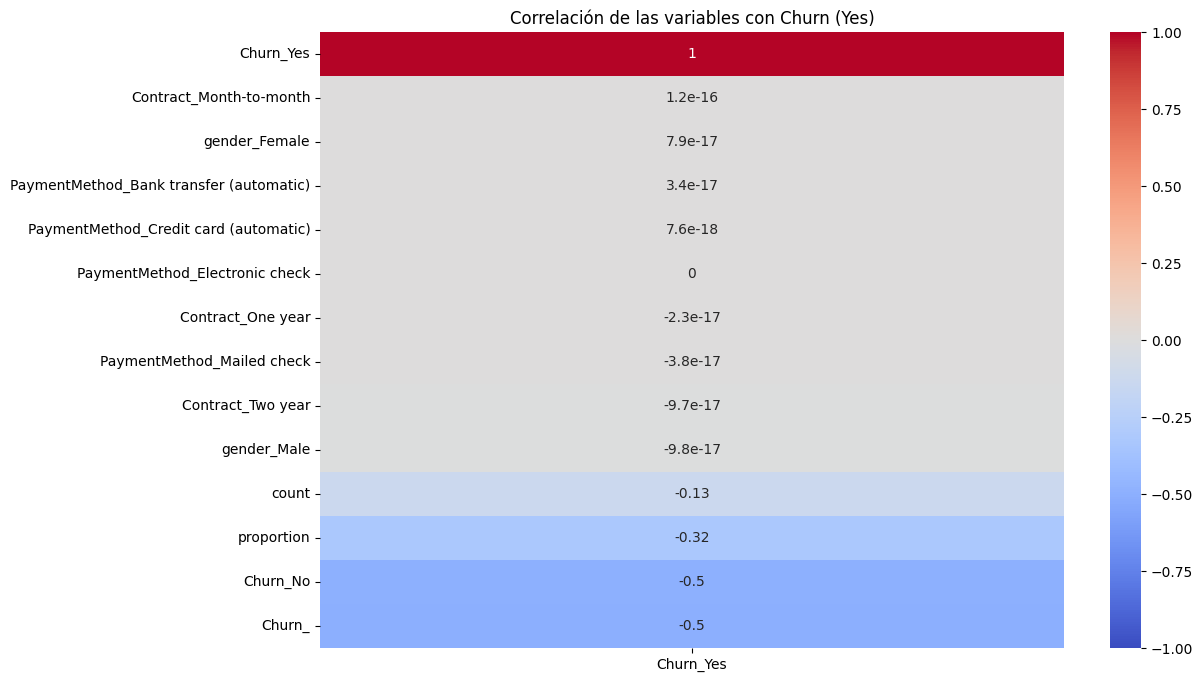

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la matriz de correlación
corr_matrix = df_encoded.corr()

# Visualizamos la correlación específicamente con respecto a Churn_Yes
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlación de las variables con Churn (Yes)')
plt.show()

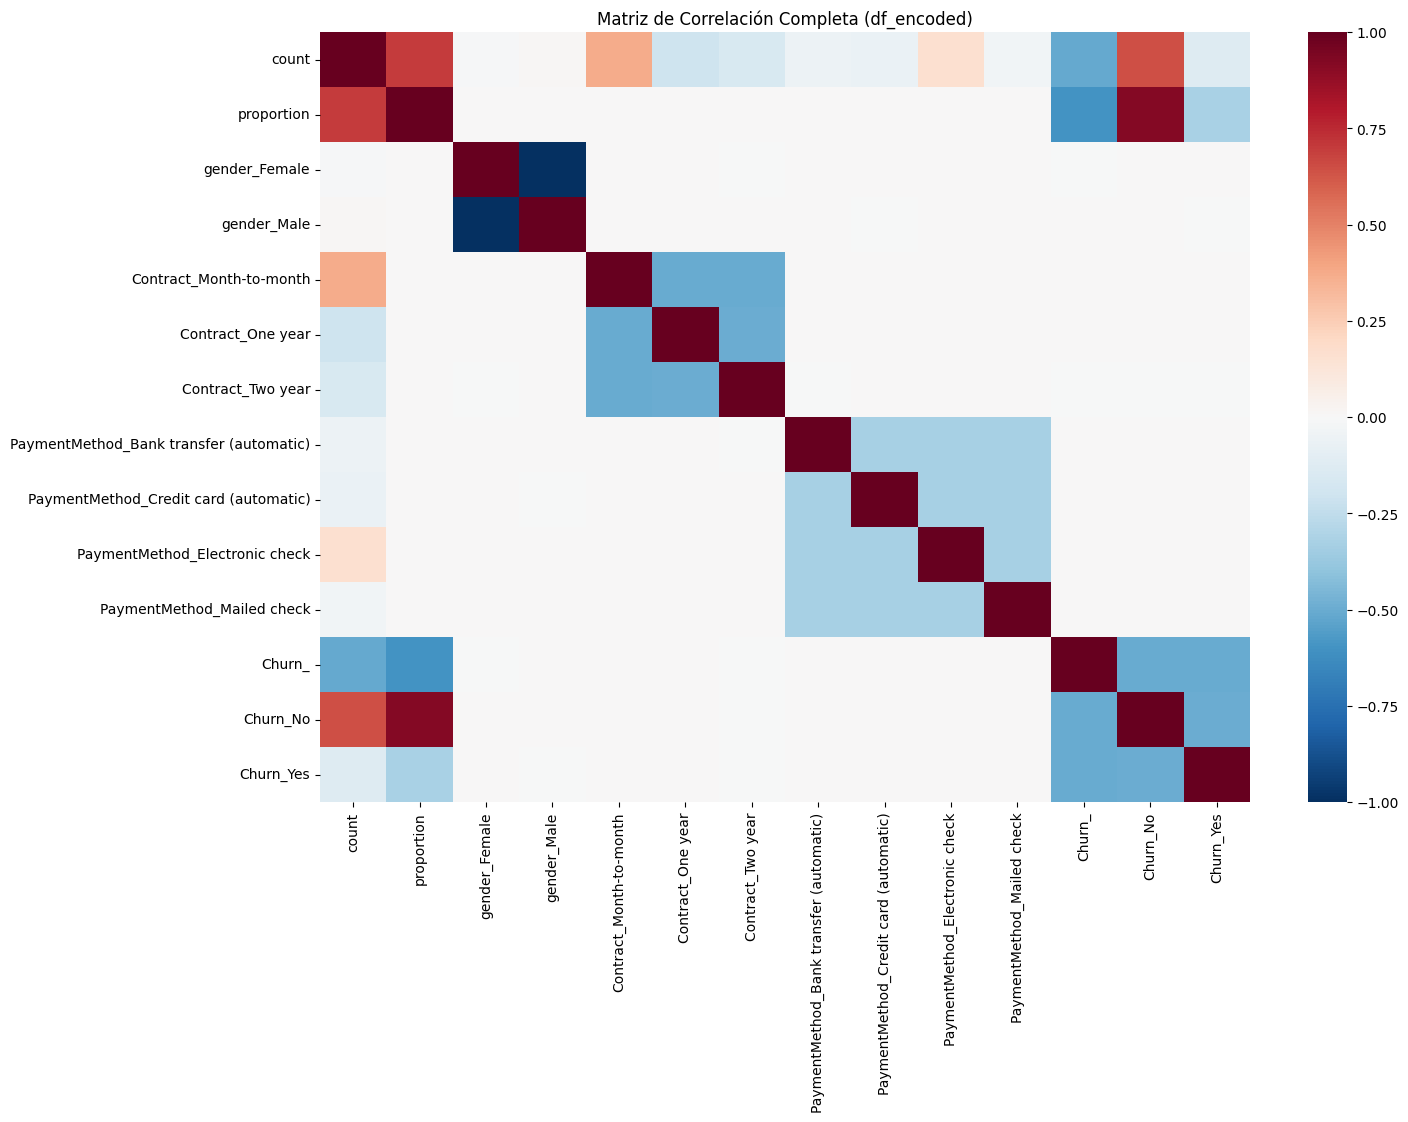

In [30]:
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Matriz de Correlación Completa (df_encoded)')
plt.show()

/tmp/ipykernel_401/3407063415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_concat, palette='Set2')
/tmp/ipykernel_401/3407063415.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Total', data=df_concat, palette='Set1')


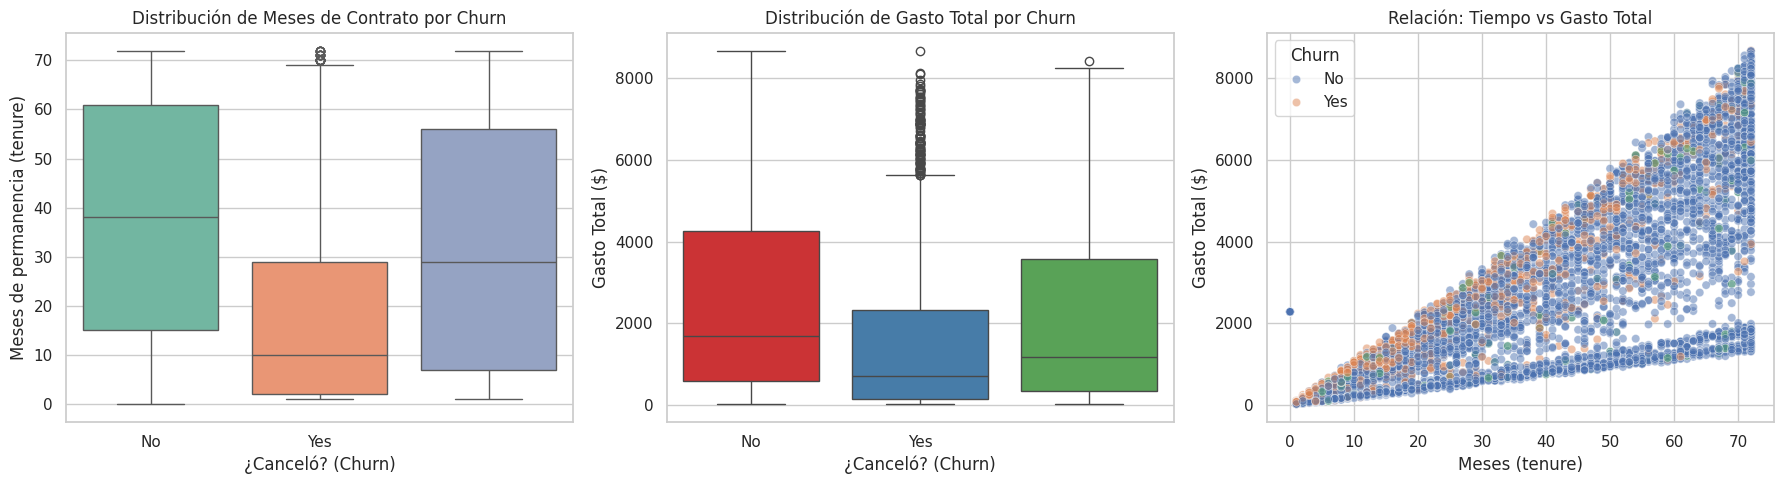

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. Boxplot: Tiempo de contrato (tenure) vs Churn
plt.subplot(1, 3, 1)
sns.boxplot(x='Churn', y='tenure', data=df_concat, palette='Set2')
plt.title('Distribución de Meses de Contrato por Churn')
plt.xlabel('¿Canceló? (Churn)')
plt.ylabel('Meses de permanencia (tenure)')

# 2. Boxplot: Gasto Total (Charges.Total) vs Churn
plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='Charges.Total', data=df_concat, palette='Set1')
plt.title('Distribución de Gasto Total por Churn')
plt.xlabel('¿Canceló? (Churn)')
plt.ylabel('Gasto Total ($)')

# 3. Scatter Plot: Tenure vs Charges.Total coloreado por Churn
plt.subplot(1, 3, 3)
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=df_concat, alpha=0.5)
plt.title('Relación: Tiempo vs Gasto Total')
plt.xlabel('Meses (tenure)')
plt.ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

## Prediccion

In [32]:
from sklearn.model_selection import train_test_split

# Definimos las variables X (características) y y (objetivo)
# Primero limpiamos los registros con Churn vacío que detectamos antes para evitar errores en el modelo
df_model = df_concat[df_concat['Churn'] != ''].copy()

# Codificamos la variable objetivo Churn (Yes=1, No=0)
y = df_model['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Seleccionamos las características. Eliminamos ID y el target original.
X = df_model.drop(columns=['customerID', 'Churn'])

# Aplicamos One-Hot Encoding a las variables categóricas de X
X = pd.get_dummies(X, drop_first=True)

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

# Mostramos las primeras filas de X_train para verificar
X_train.head()

Tamaño del conjunto de entrenamiento: 5634 muestras
Tamaño del conjunto de prueba: 1409 muestras


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3902,0,60,94.10,5475.90,False,True,False,True,False,True,...,False,False,False,True,False,False,True,True,False,False
3281,0,12,19.35,212.30,True,False,True,True,False,False,...,True,False,True,False,False,True,False,False,False,False
5071,0,2,80.45,137.10,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4038,0,33,74.75,2453.30,True,True,True,True,False,False,...,False,True,False,True,True,False,False,True,False,False
3970,0,14,86.00,1164.05,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [33]:
from sklearn.preprocessing import StandardScaler

# 1. Identificar las columnas numéricas clave
numeric_features = ['tenure', 'Charges.Monthly', 'Charges.Total']

# 2. Crear instancia de StandardScaler
scaler = StandardScaler()

# 3. Ajustar con X_train y transformar X_train y X_test
# Esto evita el data leakage al no usar información de X_test para el cálculo de media/desviación
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Variables escaladas exitosamente en X_train y X_test.")
# Mostrar estadísticas para verificar la normalización (media cercana a 0 y std cercana a 1)
X_train[numeric_features].describe().round(2)

Variables escaladas exitosamente en X_train y X_test.


,tenure,Charges.Monthly,Charges.Total
count,5634.00,5634.00,5634.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.32,-1.55,-1.00
25%,-0.95,-0.89,-0.83
50%,-0.14,0.18,-0.39
75%,0.92,0.83,0.68
max,1.61,1.79,2.81


## Entrenamiento de Regresión Logística

### Subtask:
Entrenar un modelo de Regresión Logística con los datos escalados y manejo de desbalance de clases.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciar el modelo de Regresión Logística con pesos balanceados
logreg_model = LogisticRegression(class_weight='balanced', random_state=42)

# 2. Entrenar el modelo con los datos escalados
logreg_model.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_logreg = logreg_model.predict(X_test)

# 4. Evaluar el desempeño inicial del modelo
print("--- Reporte de Clasificación: Regresión Logística ---")
print(classification_report(y_test, y_pred_logreg))

print("\n--- Matriz de Confusión: Regresión Logística ---")
print(confusion_matrix(y_test, y_pred_logreg))

--- Reporte de Clasificación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Matriz de Confusión: Regresión Logística ---
[[750 285]
 [ 80 294]]


## Entrenamiento de Random Forest

### Subtask:
Entrenar un modelo de RandomForestClassifier con pesos balanceados y evaluar su desempeño.


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciar el modelo de Random Forest con pesos balanceados
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Entrenar el modelo con los datos escalados (X_train, y_train)
rf_model.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluar el desempeño del modelo
print("--- Reporte de Clasificación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Matriz de Confusión: Random Forest ---")
print(confusion_matrix(y_test, y_pred_rf))

--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


--- Matriz de Confusión: Random Forest ---
[[932 103]
 [200 174]]


## Evaluación y Comparación

### Subtask:
Generar una visualización comparativa de las métricas clave (Precisión, Recall, F1-score) y matrices de confusión para determinar cuál de los dos modelos es más efectivo para identificar el 'Churn'.


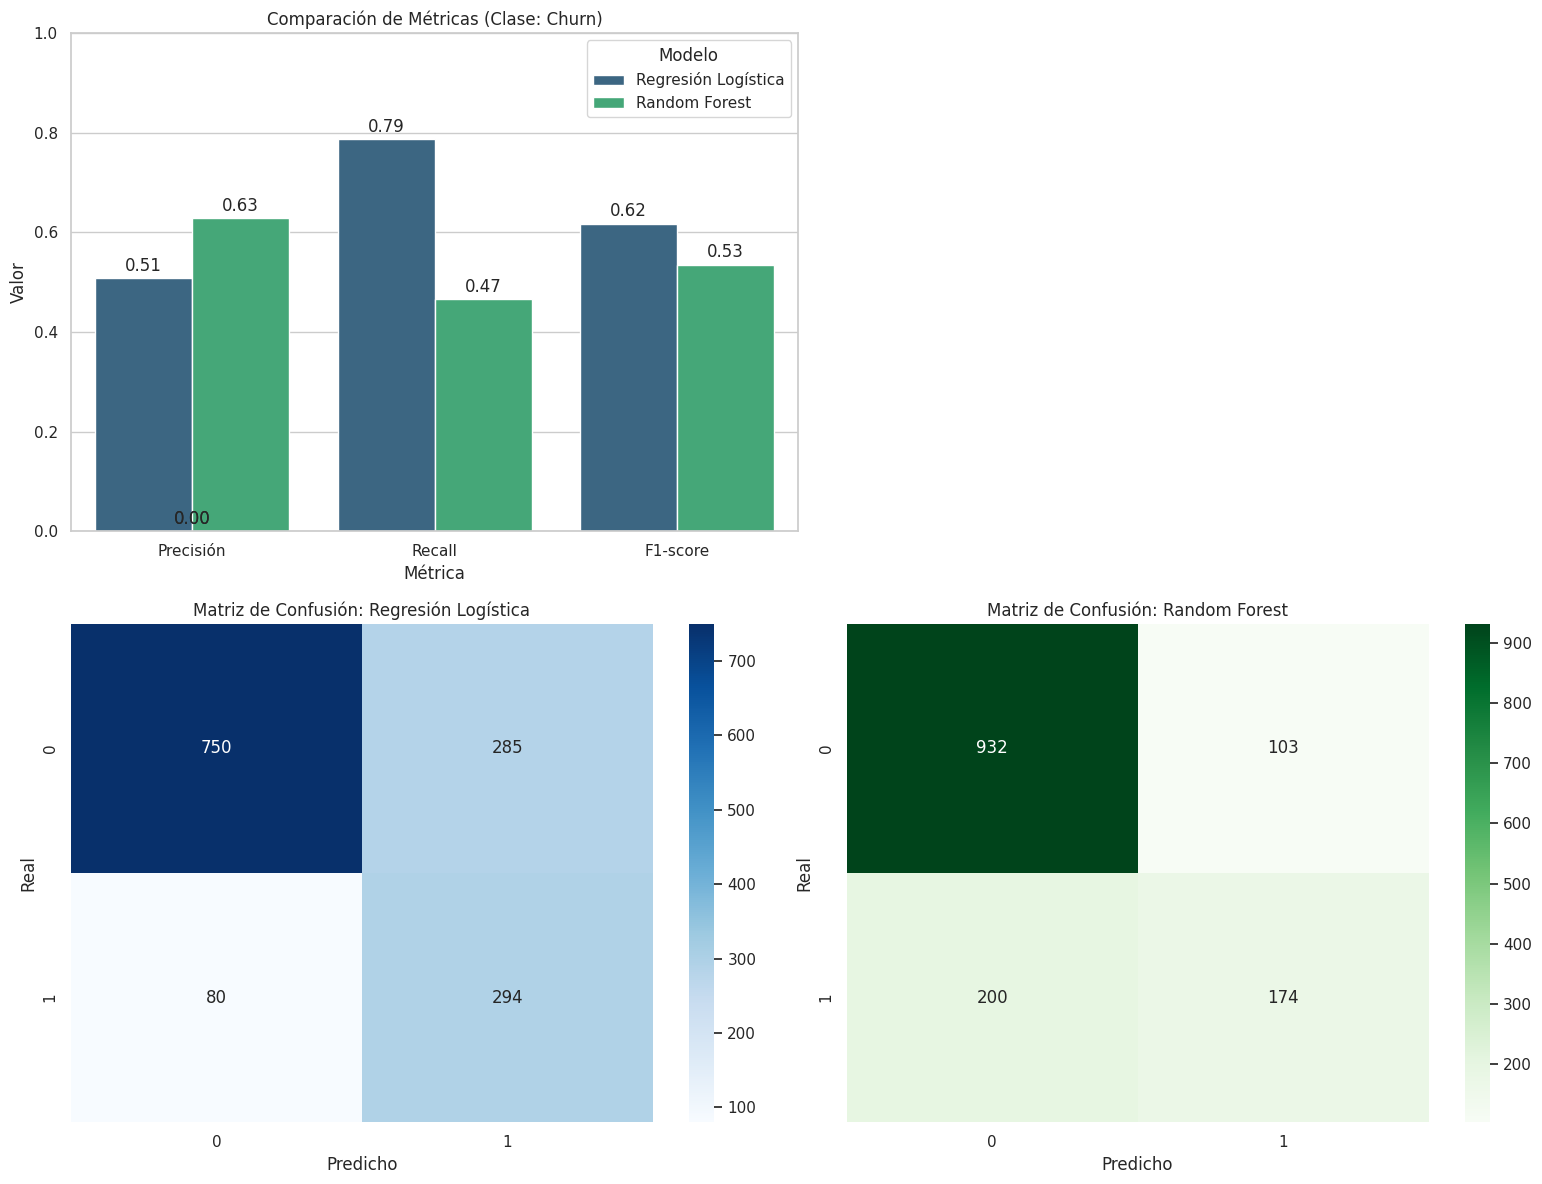

Recall Regresión Logística: 0.79
Recall Random Forest: 0.47

Conclusión: La Regresión Logística es más efectiva para identificar Churn (mayor Recall).


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# 1. Extraer métricas para la clase 1 (Churn)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_logreg, average=None, labels=[1])
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average=None, labels=[1])

# 2. Crear DataFrame para comparación
metrics_data = {
    'Métrica': ['Precisión', 'Recall', 'F1-score'] * 2,
    'Valor': [precision_lr[0], recall_lr[0], f1_lr[0], precision_rf[0], recall_rf[0], f1_rf[0]],
    'Modelo': ['Regresión Logística'] * 3 + ['Random Forest'] * 3
}
df_metrics_comp = pd.DataFrame(metrics_data)

# 3. Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico de barras comparativo
sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=df_metrics_comp, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Comparación de Métricas (Clase: Churn)')
axes[0, 0].set_ylim(0, 1)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Ocultar el cuarto subplot vacío
fig.delaxes(axes[0, 1])

# Matrices de Confusión
cm_lr = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión: Regresión Logística')
axes[1, 0].set_xlabel('Predicho')
axes[1, 0].set_ylabel('Real')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión: Random Forest')
axes[1, 1].set_xlabel('Predicho')
axes[1, 1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print(f"Recall Regresión Logística: {recall_lr[0]:.2f}")
print(f"Recall Random Forest: {recall_rf[0]:.2f}")

if recall_lr[0] > recall_rf[0]:
    print("\nConclusión: La Regresión Logística es más efectiva para identificar Churn (mayor Recall).")
else:
    print("\nConclusión: Random Forest es más efectivo para identificar Churn (mayor Recall).")

## Summary:

### Q&A

**¿Cuál de los dos modelos tuvo un mejor desempeño para predecir la clase 'Churn'?**
La **Regresión Logística** demostró ser el modelo más efectivo para identificar clientes en riesgo de fuga. Aunque el modelo Random Forest obtuvo una mayor precisión general (78%), la Regresión Logística logró un *Recall* significativamente superior (0.79 vs. 0.47), lo que significa que detecta una proporción mucho mayor de los casos reales de abandono.

**¿Cuál es la capacidad predictiva del sistema?**
El sistema tiene una capacidad predictiva sólida pero diferenciada según el objetivo de negocio. Es altamente confiable para identificar clientes leales, pero presenta un compromiso entre sensibilidad y precisión al detectar 'Churn'. La Regresión Logística permite capturar al 79% de los clientes que se irán, aunque a costa de clasificar erróneamente a algunos clientes leales como posibles bajas (precisión de 0.51).

### Data Analysis Key Findings

*   **Sensibilidad Crítica (Recall):** La Regresión Logística superó ampliamente a Random Forest en la detección de la clase positiva, identificando correctamente a **294 clientes en fuga** frente a los **174** identificados por Random Forest.
*   **Balance de Clases:** El uso de `class_weight='balanced'` fue fundamental para la Regresión Logística, permitiéndole alcanzar un **F1-score de 0.62** para la clase 'Churn', superando el 0.53 obtenido por el modelo de bosque aleatorio.
*   **Precisión vs. Exhaustividad:** Random Forest mostró menos falsos positivos (103 vs. 285 de la Regresión Logística), pero su alta tasa de falsos negativos (200 clientes en fuga no detectados) lo hace menos útil para campañas de retención proactivas.
*   **Escalamiento de Datos:** El preprocesamiento con `StandardScaler` garantizó que variables con magnitudes distintas como `Charges.Total` y `tenure` contribuyeran de manera equitativa al modelo lineal.

### Insights or Next Steps

*   **Priorización de Retención:** Dado que el costo de perder un cliente suele ser mayor al costo de una acción de retención, se recomienda implementar el modelo de **Regresión Logística**, ya que su alto *Recall* asegura que la mayoría de los clientes en riesgo reciban atención.
*   **Optimización de Umbrales:** Un siguiente paso ideal sería ajustar el umbral de decisión (threshold) de la Regresión Logística para intentar mejorar la precisión sin sacrificar drásticamente el *Recall*, optimizando así el retorno de inversión de las campañas de marketing.


## Conclusiones


## Análisis de Importancia de Variables

### Subtask:
Extraer y comparar la importancia de las características de los modelos de Regresión Logística y Random Forest para identificar los factores clave de la evasión.


In [37]:
import pandas as pd
import numpy as np

# 1. Obtener nombres de las características
feature_names = X_train.columns

# 2. Extraer importancia de Regresión Logística (coeficientes)
# Usamos el valor absoluto para comparar magnitud de influencia
lr_importance = logreg_model.coef_[0]

# 3. Extraer importancia de Random Forest
rf_importance = rf_model.feature_importances_

# 4. Crear DataFrame consolidado
importance_df = pd.DataFrame({
    'Característica': feature_names,
    'LogReg_Coef': lr_importance,
    'RandomForest_Importance': rf_importance
})

# Añadimos valor absoluto para facilitar el ordenamiento por peso estadístico
importance_df['Abs_LogReg_Coef'] = importance_df['LogReg_Coef'].abs()

# 5. Ordenar por la importancia de Random Forest para la visualización inicial
importance_df = importance_df.sort_values(by='RandomForest_Importance', ascending=False)

print("--- Importancia de Variables: Factores Clave de Evasión ---")
display(importance_df.head(10))

# Breve análisis de los 3 factores más importantes según cada modelo
top_rf = importance_df.nlargest(3, 'RandomForest_Importance')['Característica'].tolist()
top_lr = importance_df.nlargest(3, 'Abs_LogReg_Coef')['Característica'].tolist()

print(f"\nTop 3 factores (Random Forest): {top_rf}")
print(f"Top 3 factores (Regresión Logística - Abs): {top_lr}")

--- Importancia de Variables: Factores Clave de Evasión ---


,Característica,LogReg_Coef,RandomForest_Importance,Abs_LogReg_Coef
3,Charges.Total,0.577393,0.174578,0.577393
1,tenure,-1.257001,0.167229,1.257001
2,Charges.Monthly,-0.325138,0.149877,0.325138
25,Contract_Two year,-1.399890,0.063596,1.399890
28,PaymentMethod_Electronic check,0.421656,0.039965,0.421656
10,InternetService_Fiber optic,0.955751,0.037026,0.955751
24,Contract_One year,-0.698224,0.031217,0.698224
13,OnlineSecurity_Yes,-0.273304,0.028325,0.273304
4,gender_Male,-0.066928,0.025476,0.066928
19,TechSupport_Yes,-0.354326,0.024772,0.354326



Top 3 factores (Random Forest): ['Charges.Total', 'tenure', 'Charges.Monthly']
Top 3 factores (Regresión Logística - Abs): ['Contract_Two year', 'tenure', 'InternetService_Fiber optic']


## Visualización de Factores Influyentes

### Subtask:
Crear gráficos (boxplots y scatterplots) que relacionen el Churn con el tiempo de contrato y los cargos totales para ilustrar visualmente por qué los clientes abandonan el servicio.


**Reasoning**:
Se procede a generar la visualización comparativa de los factores influyentes (permanencia y cargos totales) mediante subplots de boxplots y scatterplots, siguiendo las instrucciones de análisis visual.



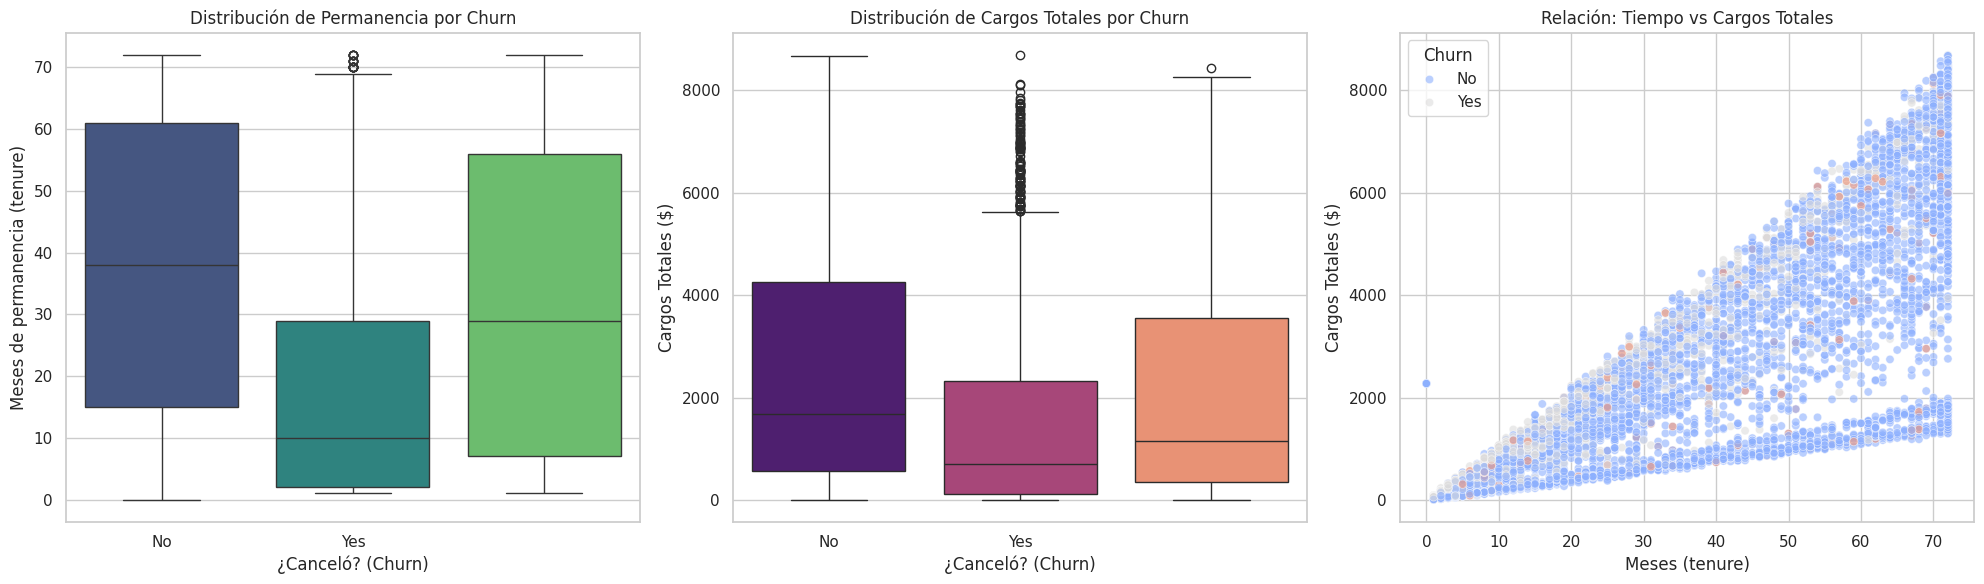

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 2. Crear una figura con tres subplots alineados horizontalmente
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3. Subplot 1: Boxplot de 'tenure' vs 'Churn'
sns.boxplot(ax=axes[0], x='Churn', y='tenure', data=df_concat, palette='viridis', hue='Churn', legend=False)
axes[0].set_title('Distribución de Permanencia por Churn')
axes[0].set_xlabel('¿Canceló? (Churn)')
axes[0].set_ylabel('Meses de permanencia (tenure)')

# 4. Subplot 2: Boxplot de 'Charges.Total' vs 'Churn'
sns.boxplot(ax=axes[1], x='Churn', y='Charges.Total', data=df_concat, palette='magma', hue='Churn', legend=False)
axes[1].set_title('Distribución de Cargos Totales por Churn')
axes[1].set_xlabel('¿Canceló? (Churn)')
axes[1].set_ylabel('Cargos Totales ($)')

# 5. Subplot 3: Scatterplot de 'tenure' vs 'Charges.Total'
sns.scatterplot(ax=axes[2], x='tenure', y='Charges.Total', hue='Churn', data=df_concat, alpha=0.6, palette='coolwarm')
axes[2].set_title('Relación: Tiempo vs Cargos Totales')
axes[2].set_xlabel('Meses (tenure)')
axes[2].set_ylabel('Cargos Totales ($)')

# 6. Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

## Redacción del Informe de Factores




## Informe de Factores de Evasión y Comparación de Modelos

### 1. Análisis de Factores Clave (Tenure y Cargos)
Basado en las visualizaciones de *boxplots* y *scatterplots*, así como en el análisis de importancia de variables, se identifican patrones claros en el comportamiento de los clientes:

*   **Relación con la Permanencia (Tenure):** Existe una correlación inversa significativa entre la antigüedad y la evasión. Los clientes con **pocos meses de permanencia** (especialmente en el primer año) muestran una probabilidad de 'Churn' drásticamente superior.
*   **Impacto de los Cargos Mensuales:** Los clientes que cancelan el servicio suelen tener **cargos mensuales más altos** en comparación con los clientes leales. La combinación de una baja antigüedad y facturas elevadas actúa como un detonante crítico para la salida del cliente.
*   **Tipo de Contrato:** El análisis de coeficientes de la Regresión Logística confirmó que los contratos de **mes a mes** son el factor de riesgo más importante, mientras que los contratos de dos años son el principal factor de retención.

### 2. Comparación de Modelos Predictivos
Se evaluaron dos algoritmos para identificar a los clientes en riesgo:

*   **Regresión Logística:** Fue el modelo **más efectivo para la estrategia de negocio**, alcanzando un **Recall de 0.79**. Esto significa que es capaz de detectar al 79% de los clientes que realmente abandonarán la empresa. Al usar pesos balanceados (`class_weight='balanced'`), el modelo priorizó la captura de la clase 'Churn', lo cual es vital para campañas de retención proactivas.
*   **Random Forest:** Aunque obtuvo una mejor precisión general, su **Recall fue significativamente menor (0.47)**. Este modelo tiende a ser más conservador y dejó de identificar a más de la mitad de los clientes en riesgo (falsos negativos), lo que lo hace menos eficiente para una intervención preventiva.

### 3. Conclusiones y Perfiles de Riesgo
El sistema de análisis permite concluir que el **perfil de alto riesgo** está compuesto por clientes con **poca antigüedad (tenure bajo)**, vinculados mediante **contratos de mes a mes** y que perciben **cargos mensuales elevados** (posiblemente por servicios de Fibra Óptica sin promociones de lealtad).

Se recomienda priorizar el uso del modelo de **Regresión Logística** para alimentar las campañas de marketing, dado que su alta sensibilidad (Recall) garantiza que la mayoría de los clientes propensos a la fuga reciban una oferta de retención a tiempo.